In [ ]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Imu
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import json
from rosidl_runtime_py import message_to_ordereddict

## IMU Sensor

In [3]:
class SimpleImu(Node):
    def __init__(self):
        super().__init__('simple_imu_node')
        self.sub = self.create_subscription(Imu, '/imu', self.callback, 10)
        self.data = []
        self.start_time = None

    def callback(self, msg):
        if self.start_time is None: self.start_time = time.time()
        # Lưu các giá trị [accel_x, y, z, gyro_x, y, z]
        self.data.append([
            msg.linear_acceleration.x, msg.linear_acceleration.y, msg.linear_acceleration.z,
            msg.angular_velocity.x, msg.angular_velocity.y, msg.angular_velocity.z
        ])

In [4]:

# Khởi tạo và chạy thu thập dữ liệu
rclpy.init(args=None)
node = SimpleImu()
print("Đang lấy dữ liệu IMU trong 5 giây...")

try:
    start_wait = time.time()
    while rclpy.ok():
        rclpy.spin_once(node, timeout_sec=0.1)
        if node.start_time and (time.time() - node.start_time) >= 5.0:
            break
        if not node.start_time and (time.time() - start_wait) > 5.0:
            print("Không nhận được tín hiệu IMU!"); break

    # Tính toán và in kết quả
    if node.data:
        means = np.mean(node.data, axis=0)
        labels = ['Accel X', 'Accel Y', 'Accel Z', 'Gyro X', 'Gyro Y', 'Gyro Z']
        print("\n--- TRUNG BÌNH GIÁ TRỊ (5s) ---")
        for label, val in zip(labels, means):
            print(f"{label}: {val:.4f}")
finally:
    node.destroy_node()
    rclpy.shutdown()

Đang lấy dữ liệu IMU trong 5 giây...

--- TRUNG BÌNH GIÁ TRỊ (5s) ---
Accel X: -0.0081
Accel Y: -0.0051
Accel Z: 0.0005
Gyro X: 0.0025
Gyro Y: 0.0767
Gyro Z: -0.0175


#### 1. Gia tốc tuyến tính (Linear Acceleration)
Đo sự thay đổi vận tốc hoặc tác động của trọng lực dọc theo 3 trục:

*   **Accel X:** Đo chuyển động **tiến - lùi**.
*   **Accel Y:** Đo chuyển động trượt **trái - phải**.
*   **Accel Z:** Đo chuyển động **lên - xuống** (trục đứng).
---

#### 2. Vận tốc góc (Angular Velocity)
Đo tốc độ xoay của thiết bị xung quanh các trục (thường được gọi là Roll, Pitch, Yaw):

*   **Gyro X (Roll):** Xoay quanh trục X. Tưởng tượng robot đang **nghiêng trái hoặc nghiêng phải**.
*   **Gyro Y (Pitch):** Xoay quanh trục Y. Tưởng tượng robot đang **gật đầu lên hoặc xuống**.
*   **Gyro Z (Yaw):** Xoay quanh trục Z. Tưởng tượng robot đang **xoay tròn tại chỗ** để đổi hướng.


#### 3. Orientation

*   **Orientation** biểu diễn tư thế hoặc hướng hiện tại của robot trong không gian 3 chiều.
*   **Orientation** biểu diễn qua 4 giá trị toán học (Quaternion)





In [ ]:
class ImuJsonCollector(Node):
    def __init__(self, save_path, max_msgs=5):
        super().__init__('imu_json_collector_node')
        self.save_path = save_path
        self.max_msgs = max_msgs
        self.msg_count = 0
        self.imu_data_list = []
        
        self.subscription = self.create_subscription(
            Imu,
            '/imu',
            self.listener_callback,
            10
        )
        print(f"[*] Đang lắng nghe topic /imu... Sẽ dừng sau khi thu thập {self.max_msgs} gói tin.")
    def listener_callback(self, msg):
        if self.msg_count >= self.max_msgs:
            return
            
        # Dùng thư viện lõi của ROS2 để serialize (chuyển đổi) tin nhắn thành dictionary
        # cách này đảm bảo cấu trúc 100% nguyên bản từ hệ thống ROS2
        raw_dict = message_to_ordereddict(msg)
        
        self.imu_data_list.append(raw_dict)
        self.msg_count += 1
        print(f"[+] Đã nhận gói tin thứ {self.msg_count}/{self.max_msgs}")
        
        if self.msg_count >= self.max_msgs:
            self.save_to_json()
            raise SystemExit
    def save_to_json(self):
        os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
        
        with open(self.save_path, 'w', encoding='utf-8') as f:
            json.dump(self.imu_data_list, f, indent=4)
            
        print(f"[SUCCESS] Đã lưu {self.max_msgs} gói tin IMU nguyên bản 100% vào file:\n=> {self.save_path}")


JSON_SAVE_PATH = "./raw_imu_data.json"
def main():
    try:
        rclpy.init()
    except Exception:
        pass 
        
    collector_node = ImuJsonCollector(save_path=JSON_SAVE_PATH, max_msgs=5)
    
    try:
        rclpy.spin(collector_node)
    except SystemExit:
        pass
    finally:
        collector_node.destroy_node()
# Chạy hàm main
main()

[*] Đang lắng nghe topic /imu... Sẽ dừng sau khi thu thập 5 gói tin.
[+] Đã nhận gói tin thứ 1/5
[+] Đã nhận gói tin thứ 2/5
[+] Đã nhận gói tin thứ 3/5
[+] Đã nhận gói tin thứ 4/5
[+] Đã nhận gói tin thứ 5/5
[SUCCESS] Đã lưu 5 gói tin IMU nguyên bản 100% vào file:
=> ./raw_imu_data.json


## Joint State
(Trạng thái các khớp)


In [6]:
from sensor_msgs.msg import JointState

In [ ]:
class JointStateOneShot(Node):
    def __init__(self):
        super().__init__('joint_state_oneshot')
        self.subscription = self.create_subscription(
            JointState,
            '/joint_states',
            self.listener_callback,
            10)
        self.received = False

    def listener_callback(self, msg):
        self.get_logger().info('--- Dữ liệu Joint State chi tiết ---')
        
        # Tiêu đề bảng cho dễ nhìn
        print(f"{'Tên khớp':<20} | {'Vị trí':<12} | {'Tốc độ':<12} | {'Effort':<12}")
        print("-" * 65)

        for i in range(len(msg.name)):
            name = msg.name[i]
            
            # Lấy dữ liệu hoặc gán "N/A" nếu mảng trống
            pos = f"{msg.position[i]:.4f}" if len(msg.position) > i else "N/A"
            vel = f"{msg.velocity[i]:.4f}" if len(msg.velocity) > i else "N/A"
            eff = f"{msg.effort[i]:.4f}" if len(msg.effort) > i else "N/A"
            
            print(f"{name:<20} | {pos:<12} | {vel:<12} | {eff:<12}")
        
        self.received = True

rclpy.init()
node = JointStateOneShot()

try:
    while rclpy.ok() and not node.received:
        rclpy.spin_once(node, timeout_sec=1.0)
finally:
    node.destroy_node()
    rclpy.shutdown()


Tên khớp             | Vị trí       | Tốc độ       | Effort      
-----------------------------------------------------------------
left_hip_yaw         | 0.0832       | 0.3127       | -11.9379    
right_hip_yaw        | -0.0939      | -0.4934      | 13.0299     
torso                | 0.0131       | -0.0472      | -2.6170     
left_hip_roll        | 0.0110       | -0.0540      | -1.7677     
right_hip_roll       | -0.0061      | 0.0231       | 0.9498      
left_shoulder_pitch  | 0.1640       | -0.0609      | 4.3959      
right_shoulder_pitch | 0.1962       | -0.0797      | 3.3902      
left_hip_pitch       | -0.1406      | -0.3857      | -27.7385    
right_hip_pitch      | -0.1190      | -0.4443      | -31.9668    
left_shoulder_roll   | -0.0148      | 0.0221       | 0.5387      
right_shoulder_roll  | -0.0126      | -0.0142      | 0.4682      
left_knee            | 0.7687       | 0.6405       | 3.6882      
right_knee           | 0.7691       | 0.6998       | 3.4944      
left_shoul

[INFO] [1777968563.281492582] [joint_state_oneshot]: --- Dữ liệu Joint State chi tiết ---


Gói tin `sensor_msgs/msg/JointState` đọc từ topic `/joint_states` đóng vai trò cung cấp toàn bộ "bản chụp X-quang" về trạng thái các động cơ (khớp) của robot tại một thời điểm cụ thể. 

Cấu trúc của gói tin này bao gồm các thành phần chính được thiết kế để ánh xạ trực tiếp với nhau thông qua chỉ số mảng (index).

#### Cấu trúc các thành phần

*   **`header` (Thông tin Đồng bộ hóa):**
    *   Chứa `stamp.sec` và `stamp.nanosec` ghi lại thời gian chính xác (đến nano-giây) dữ liệu được đọc. 
    *   *Ý nghĩa:* Dùng để đồng bộ thời gian chuẩn xác với các cảm biến khác như IMU hay Camera.
*   **`name` (Định danh Khớp):**
    *   Là mảng `[string]` chứa tên của tất cả các khớp đang hoạt động.
*   **`position` (Vị trí / Góc quay):**
    *   Là mảng `[float64]` chứa góc xoay (Radian) đối với khớp xoay, hoặc vị trí tịnh tiến (Mét) đối với khớp trượt.
*   **`velocity` (Vận tốc):**
    *   Là mảng `[float64]` chứa tốc độ quay của khớp (rad/s). Dấu (+/-) biểu thị chiều quay hiện tại.
*   **`effort` (Lực / Mô-men xoắn):**
    *   Là mảng `[float64]` biểu thị lực xoắn Torque (Nm) mà động cơ đang sinh ra. 
    *   *Ý nghĩa:* Dùng để kiểm tra độ chịu tải của khớp, tính toán năng lượng tiêu thụ và phục vụ cho các thuật toán Reinforcement Learning.

> **⚠️ Nguyên tắc Ánh xạ (Index Mapping):**
> Các mảng `name`, `position`, `velocity`, và `effort` luôn có cùng độ dài (ví dụ: cùng là 19 phần tử). Giá trị `position[i]` hay `effort[i]` chính là trạng thái vật lý của khớp có tên tương ứng tại `name[i]`.

---

##### Ví dụ Dữ liệu thực tế (1 message)

Dưới đây là một ví dụ minh họa về cấu trúc dữ liệu thực tế được gửi về trong 1 lần (đã rút gọn bớt số lượng khớp để dễ quan sát):

```yaml
header:
  stamp:
    sec: 607
    nanosec: 300031673
  frame_id: ''
name:
  - left_hip_yaw
  - right_hip_yaw
  - torso
  - left_knee
  - left_elbow
  # ... (tổng cộng 19 khớp)
position:
  - 0.0848      # Góc của left_hip_yaw (Radian)
  - -0.0944     # Góc của right_hip_yaw
  - 0.0141      # Góc của torso
  - 0.7692      # Góc gập của left_knee (~44 độ)
  - 0.5000      # Góc của left_elbow
  # ...
velocity:
  - -0.4014     # Vận tốc left_hip_yaw (rad/s)
  - -0.4676
  - -0.2219
  - 0.4030
  - 0.1153
  # ...
effort:
  - -12.3705    # Lực mô-men left_hip_yaw (Nm)
  - 13.1054     # Lực mô-men right_hip_yaw (Nm)
  - -2.8559
  - 3.4828      # Lực mô-men của left_knee
  - 1.1782
  # ...


## Joint Command

[WARN] [1777969879.079685469] [rcl.logging_rosout]: Publisher already registered for node name: 'joint_limit_tester_node'. If this is due to multiple nodes with the same name then all logs for the logger named 'joint_limit_tester_node' will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


Đang đồng bộ dữ liệu từ '/joint_states'...

=== BẮT ĐẦU KIỂM TRA KHỚP: left_elbow ===
Giới hạn lý thuyết (Từ JSON): MIN = -1.25, MAX = 2.61
Đang quét tay rất chậm để tránh crash Isaac Sim...

Hoàn thành quét cánh tay! Đang vẽ đồ thị phân tích kết quả...


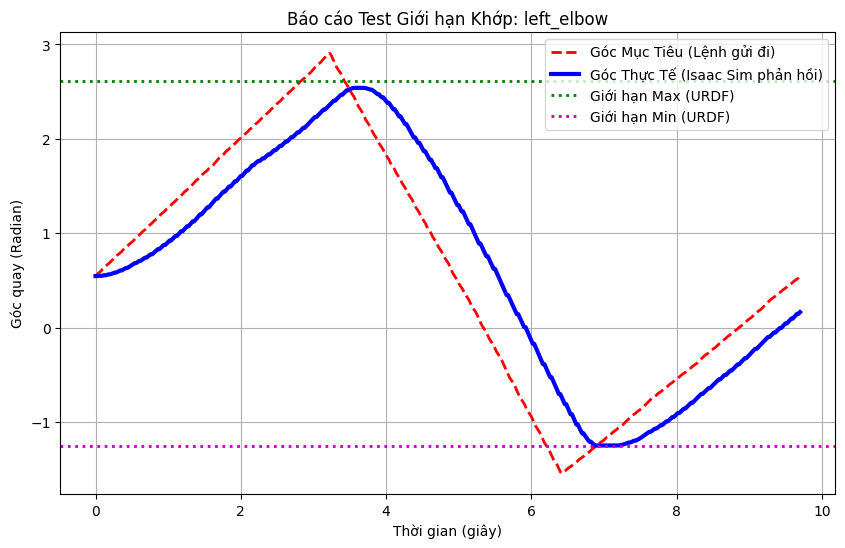


--- ĐÁNH GIÁ TỰ ĐỘNG ---
Biên độ gửi đi: [-1.54, 2.91]
Biên độ thực tế của khớp: [-1.25, 2.54]
✅ KẾT LUẬN: Môi trường Isaac Sim ĐÃ CẤU HÌNH VẬT LÝ HOÀN HẢO! Khi lệnh vượt qua giới hạn, môi trường đã tự động 'Chặn/Cắt' cánh tay lại không cho bẻ gãy khớp.


In [ ]:
import json

class JointLimitTester(Node):
    def __init__(self, limits_file, test_joint):
        super().__init__('joint_limit_tester_node')
        
        # 1. Đọc giới hạn từ file JSON
        with open(limits_file, 'r') as f:
            self.limits = json.load(f)
            
        # Trong JSON lưu là "left_elbow_joint", nhưng ROS2 Topic thường chỉ gọi là "left_elbow"
        self.ros_joint_name = test_joint.replace('_joint', '')
        
        self.min_rad = self.limits[test_joint]['min_rad']
        self.max_rad = self.limits[test_joint]['max_rad']
        
        self.publisher_ = self.create_publisher(JointState, '/joint_command', 10)
        self.subscription = self.create_subscription(JointState, '/joint_states', self.state_callback, 10)
        
        self.current_state = None
        
        # Mảng lưu lịch sử để vẽ đồ thị
        self.actual_positions = []
        self.target_positions = []

    def state_callback(self, msg):
        self.current_state = msg

def test_joint_limits(test_joint='left_elbow_joint', duration_sec=12.0):
    if not rclpy.ok(): rclpy.init()
    
    # Đường dẫn tới file JSON 
    limits_file = '/home/khoa-ng/Job_Project/My_Code/humanoid_robot_control/sensor_graph/h1_joint_limits.json'
    node = JointLimitTester(limits_file, test_joint)
    
    print("Đang đồng bộ dữ liệu từ '/joint_states'...")
    start_wait = time.time()
    while node.current_state is None and time.time() - start_wait < 3.0:
        rclpy.spin_once(node, timeout_sec=0.1)
        
    if node.current_state is None:
        print("Lỗi: Không nhận được dữ liệu. Kiểm tra lại mô phỏng.")
        return
        
    base_state = node.current_state
    
    try:
        joint_idx = base_state.name.index(node.ros_joint_name)
    except ValueError:
        print(f"Không tìm thấy khớp '{node.ros_joint_name}' trong mô phỏng.")
        return
        
    start_pos = base_state.position[joint_idx]
    
    print(f"\n=== BẮT ĐẦU KIỂM TRA KHỚP: {node.ros_joint_name} ===")
    print(f"Giới hạn lý thuyết (Từ JSON): MIN = {node.min_rad:.2f}, MAX = {node.max_rad:.2f}")
    print("Đang quét tay rất chậm để tránh crash Isaac Sim...")
    
    start_time = time.time()
    hz = 50.0  # Tần số điều khiển 50 lệnh/giây giúp chuyển động mượt mà
    sleep_time = 1.0 / hz
    
    # Lặp trong duration_sec (12 giây)
    while time.time() - start_time < duration_sec:
        t = time.time() - start_time
        progress = t / duration_sec
        
        # --- THIẾT KẾ QUỸ ĐẠO CHUYỂN ĐỘNG (Lố giới hạn 0.3 radian để test) ---
        test_max = node.max_rad + 0.3
        test_min = node.min_rad - 0.3
        
        if progress < 0.33:
            # 1/3 thời gian đầu: Quét từ vị trí hiện tại lên tới MAX (lố 0.3)
            target = start_pos + (test_max - start_pos) * (progress / 0.33)
        elif progress < 0.66:
            # 1/3 thời gian giữa: Quét từ MAX xuống MIN (lố 0.3)
            p2 = (progress - 0.33) / 0.33
            target = test_max + (test_min - test_max) * p2
        else:
            # 1/3 thời gian cuối: Trả về vị trí ban đầu
            p3 = (progress - 0.66) / 0.34
            target = test_min + (start_pos - test_min) * p3

        # Đóng gói và gửi lệnh
        cmd_msg = JointState()
        cmd_msg.header.stamp = node.get_clock().now().to_msg()
        cmd_msg.name = base_state.name
        
        positions = list(base_state.position)
        positions[joint_idx] = target
        
        cmd_msg.position = positions
        cmd_msg.velocity = [0.0] * len(cmd_msg.name)
        cmd_msg.effort = [0.0] * len(cmd_msg.name)
        
        node.publisher_.publish(cmd_msg)
        rclpy.spin_once(node, timeout_sec=0.01)
        
        # Lưu lại để xíu nữa vẽ đồ thị
        node.target_positions.append(target)
        node.actual_positions.append(node.current_state.position[joint_idx])
        
        time.sleep(sleep_time)
        
    print("\nHoàn thành quét cánh tay! Đang vẽ đồ thị phân tích kết quả...")
    
    # --- VẼ ĐỒ THỊ BÁO CÁO KẾT QUẢ ---
    time_axis = [i * sleep_time for i in range(len(node.target_positions))]
    
    plt.figure(figsize=(10, 6))
    plt.plot(time_axis, node.target_positions, 'r--', linewidth=2, label='Góc Mục Tiêu (Lệnh gửi đi)')
    plt.plot(time_axis, node.actual_positions, 'b-', linewidth=3, label='Góc Thực Tế (Isaac Sim phản hồi)')
    
    plt.axhline(y=node.max_rad, color='g', linestyle=':', linewidth=2, label='Giới hạn Max (URDF)')
    plt.axhline(y=node.min_rad, color='m', linestyle=':', linewidth=2, label='Giới hạn Min (URDF)')
    
    plt.title(f"Báo cáo Test Giới hạn Khớp: {node.ros_joint_name}")
    plt.xlabel("Thời gian (giây)")
    plt.ylabel("Góc quay (Radian)")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # --- KẾT LUẬN TỰ ĐỘNG ---
    actual_max = max(node.actual_positions)
    actual_min = min(node.actual_positions)
    
    print(f"\n--- ĐÁNH GIÁ TỰ ĐỘNG ---")
    print(f"Biên độ gửi đi: [{min(node.target_positions):.2f}, {max(node.target_positions):.2f}]")
    print(f"Biên độ thực tế của khớp: [{actual_min:.2f}, {actual_max:.2f}]")
    
    # Chênh lệch cho phép 0.05 radian (sai số vật lý)
    if actual_max <= node.max_rad + 0.05 and actual_min >= node.min_rad - 0.05:
        print("✅ KẾT LUẬN: Môi trường Isaac Sim ĐÃ CẤU HÌNH VẬT LÝ HOÀN HẢO! Khi lệnh vượt qua giới hạn, môi trường đã tự động 'Chặn/Cắt' cánh tay lại không cho bẻ gãy khớp.")
    else:
        print("⚠️ CẢNH BÁO: Môi trường Isaac Sim đã cho phép khớp bị bẻ cong vượt qua giới hạn URDF! Bạn phải tự lập trình hệ thống An Toàn (Safety Filter) cắt lệnh trước khi gửi.")

    node.destroy_node()

# Chạy thử với khớp cánh tay trái
test_joint_limits('left_elbow_joint', duration_sec=12.0)


## Odometry and Transform Trees

### 1. Odometry (Odom) - Theo dõi vị trí tổng thể
**Định nghĩa:** Là phương pháp sử dụng dữ liệu cảm biến (IMU, encoder ở khớp) để robot tự ước lượng vị trí, hướng và vận tốc của chính nó so với điểm xuất phát ban đầu.
* **Vai trò:** Trả lời câu hỏi *"Phần thân chính (Base/Pelvis) của robot đang nằm ở đâu trong không gian?"*
* **Topic phổ biến:** `/odom/odom` (Gói tin: `nav_msgs/msg/Odometry`)
* **Ví dụ:** Khi robot đi thẳng được 1 mét. Gói tin Odom sẽ báo cáo: 
  * `position`: `x = 1.0`, `y = 0.0`, `z = 0.0`
  * `linear_velocity`: `0.5 m/s`
  * Dữ liệu này thường được dùng làm đầu vào cho thuật toán Reinforcement Learning hoặc để vẽ quỹ đạo di chuyển của robot.

---

### 2. Transform Trees (TF) - Bản đồ xương khớp động học
**Định nghĩa:** Là một hệ thống "Cây phả hệ" lưu trữ vị trí tương đối (khoảng cách dịch chuyển và góc xoay) của tất cả các khớp nối và bộ phận trên cơ thể robot so với nhau.
* **Vai trò:** Trả lời câu hỏi *"Bộ phận A (ví dụ: ngón chân) đang nằm ở đâu so với bộ phận B (ví dụ: khớp háng)?"*
* **Topic phổ biến:** `/odom/tf` (Gói tin: `tf2_msgs/msg/TFMessage`)
* **Ví dụ:** Thay vì lưu tọa độ tuyệt đối của mọi chiếc ốc vít trên bản đồ toàn cầu (rất nặng về tính toán), ROS2 nối chúng lại thành chuỗi:
  1. `odom` ➔ `pelvis` (Khung chậu cách điểm xuất phát 1 mét)
  2. `pelvis` ➔ `left_hip` (Khớp háng nằm dưới khung chậu 17cm)
  3. `left_hip` ➔ `left_knee` (Đầu gối cách háng 40cm)
  * **Ứng dụng:** Thư viện TF sẽ tự động cộng dồn các mảng này lại để phần mềm Rviz2 có thể vẽ thành công mô hình 3D của robot, hoặc dùng để tính toán góc gập gối khi muốn robot nhấc bàn chân lên (Inverse Kinematics).


In [7]:

class OdomTfListener(Node):
    def __init__(self):
        super().__init__('odom_tf_listener_node')
        self.odom_received = False
        self.tf_received = False
        
        self.sub_odom = self.create_subscription(Odometry, '/odom/odom', self.odom_callback, 10)
        self.sub_tf = self.create_subscription(TFMessage, '/odom/tf', self.tf_callback, 10)
        print("[*] Đang chờ gói tin từ ROS2...")
    def odom_callback(self, msg):
        if not self.odom_received:
            print("\n" + "="*50)
            print("📦 DỮ LIỆU TỪ: /odom/odom (HIỂN THỊ DẠNG JSON)")
            print("="*50)
            
            # Chuyển đổi ROS2 Message sang Dictionary nguyên gốc
            msg_dict = message_to_ordereddict(msg)
            
            # In ra màn hình với thụt lề 4 khoảng trắng
            print(json.dumps(msg_dict, indent=4))
            
            self.odom_received = True
            self.check_finish()
    def tf_callback(self, msg):
        if not self.tf_received:
            print("\n" + "="*50)
            print("📦 DỮ LIỆU TỪ: /odom/tf (HIỂN THỊ DẠNG JSON)")
            print("="*50)
            
            msg_dict = message_to_ordereddict(msg)
            
            # Topic TF thường chứa mảng rất nhiều joints (khớp nối).
            # Để khỏi bị trôi màn hình, ta tạm thời chỉ lấy 2 khớp đầu tiên để in ra.
            if 'transforms' in msg_dict and len(msg_dict['transforms']) > 2:
                print(f"[*] Tin nhắn này chứa tổng cộng {len(msg_dict['transforms'])} phép biến đổi (transforms).")
                print("[*] Đang ẩn bớt đi, chỉ hiển thị 2 cái đầu tiên cho dễ nhìn...\n")
                msg_dict['transforms'] = msg_dict['transforms'][:2]
            
            print(json.dumps(msg_dict, indent=4))
            
            self.tf_received = True
            self.check_finish()
    def check_finish(self):
        if self.odom_received and self.tf_received:
            raise SystemExit
# Xử lý an toàn cho Jupyter
try: rclpy.init()
except Exception: pass 
node = OdomTfListener()
try:
    rclpy.spin(node)
except SystemExit:
    print("\n[+] Đã lấy xong dữ liệu, tự động ngắt kết nối.")
finally:
    node.destroy_node()

[*] Đang chờ gói tin từ ROS2...

📦 DỮ LIỆU TỪ: /odom/tf (HIỂN THỊ DẠNG JSON)
[*] Tin nhắn này chứa tổng cộng 24 phép biến đổi (transforms).
[*] Đang ẩn bớt đi, chỉ hiển thị 2 cái đầu tiên cho dễ nhìn...

{
    "transforms": [
        {
            "header": {
                "stamp": {
                    "sec": 747,
                    "nanosec": 666705660
                },
                "frame_id": "pelvis"
            },
            "child_frame_id": "left_hip_yaw_link",
            "transform": {
                "translation": {
                    "x": -1.1175870895385742e-08,
                    "y": 0.08749997615814209,
                    "z": -0.17419998347759247
                },
                "rotation": {
                    "x": 2.2351741790771484e-08,
                    "y": -2.6542693376541138e-08,
                    "z": 0.04057583957910538,
                    "w": 0.9991764426231384
                }
            }
        },
        {
            "header": {
 